In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("stealthtechnologies/rock-classification")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 213M/213M [00:13<00:00, 16.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/stealthtechnologies/rock-classification/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/stealthtechnologies/rock-classification/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/stealthtechnologies/rock-classification/versions/1):
['Rock Data']


In [ ]:
import os

# Update path to match 'Rock Data' directory
rock_data_path = os.path.join(path, 'Rock Data')

# List subdirectories in Rock Data (usually class labels)
if os.path.exists(rock_data_path):
    print(f"Classes in dataset: {os.listdir(rock_data_path)}")
else:
    print(f"Directory not found: {rock_data_path}")

Classes in dataset: ['train', 'valid', 'test', 'README.dataset.txt', 'README.roboflow.txt']



--- Sample Images from Dataset (/root/.cache/kagglehub/datasets/stealthtechnologies/rock-classification/versions/1/Rock Data) ---
Found 4212 images. Displaying 6 samples:


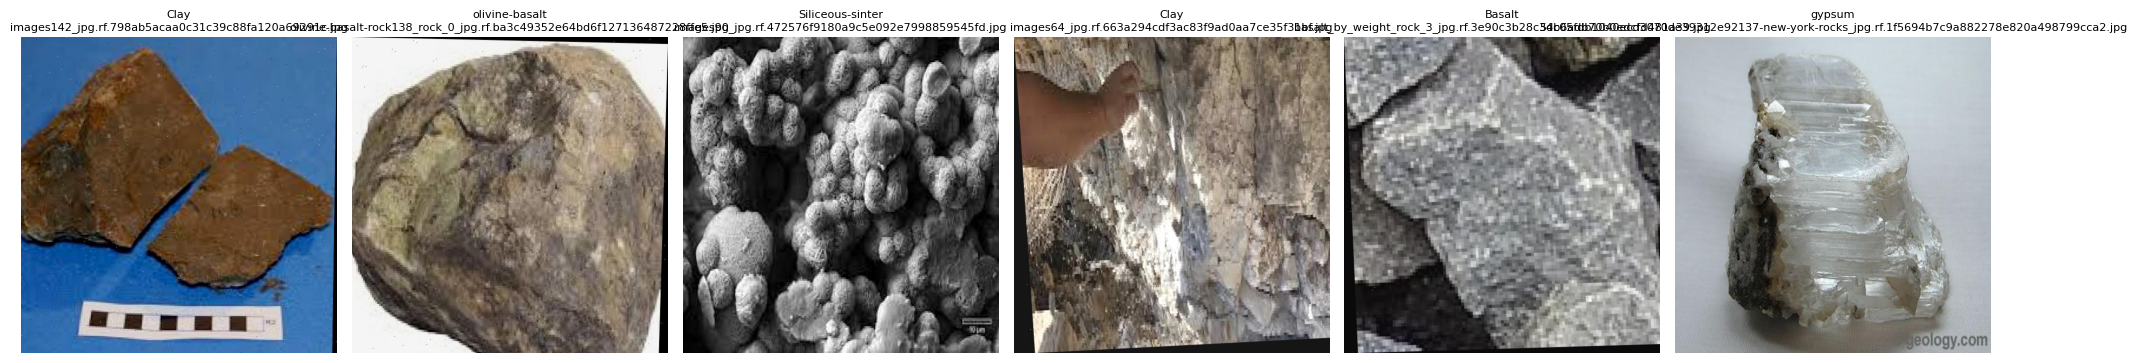

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} samples:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Display class name (parent directory) and filename
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the defined Rock Data path
rock_data_path = os.path.join(path, 'Rock Data')
print(f"\n--- Sample Images from Dataset ({rock_data_path}) ---")
display_sample_images(rock_data_path)

In [ ]:
import tensorflow as tf

# Check GPU availability
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU is available: {gpu_devices}")
    for gpu in gpu_devices:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("GPU not detected. Training will proceed on CPU (much slower).")

GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras import layers, models, optimizers

# Define paths
train_dir = os.path.join(rock_data_path, 'train')
valid_dir = os.path.join(rock_data_path, 'valid')

# Data preprocessing and augmentation
img_size = (299, 299)
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, horizontal_flip=True)
valid_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical')
valid_generator = valid_datagen.flow_from_directory(valid_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical')

# Build InceptionV3 model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model.trainable = False  # Freeze base layers

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

model.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
print("Starting training...")
history = model.fit(train_generator, validation_data=valid_generator, epochs=10)

Found 3687 images belonging to 9 classes.
Found 351 images belonging to 9 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Starting training...
Epoch 1/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 137s 997ms/step - accuracy: 0.3743 - loss: 1.7389 - val_accuracy: 0.5584 - val_loss: 1.2834
Epoch 2/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 89s 769ms/step - accuracy: 0.5359 - loss: 1.3294 - val_accuracy: 0.5755 - val_loss: 1.1951
Epoch 3/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 88s 762ms/step - accuracy: 0.5715 - loss: 1.2073 - val_accuracy: 0.6296 - val_loss: 1.1054
Epoch 4/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 89s 762ms/step - accuracy: 0.6143 - loss: 1.0982 - val_accuracy: 0.6296 - val_loss: 1.0846
Epoch 5/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 89s 762ms/step - accuracy: 0.6328 - loss: 1.0769 - val_accuracy: 0.6296 - val_loss: 1.0824
Epoch 6/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 89s 771ms/step - accuracy: 0.6461 - loss: 0.9987 - val_accuracy: 0.6154 - val_loss: 1.0703
Epoch 7/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 88s 760ms/step - a

In [ ]:
# Summary of training results
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"--- Training Summary ---")
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

--- Training Summary ---
Final Training Accuracy: 0.6900
Final Validation Accuracy: 0.6524
Final Training Loss: 0.8651
Final Validation Loss: 1.0426


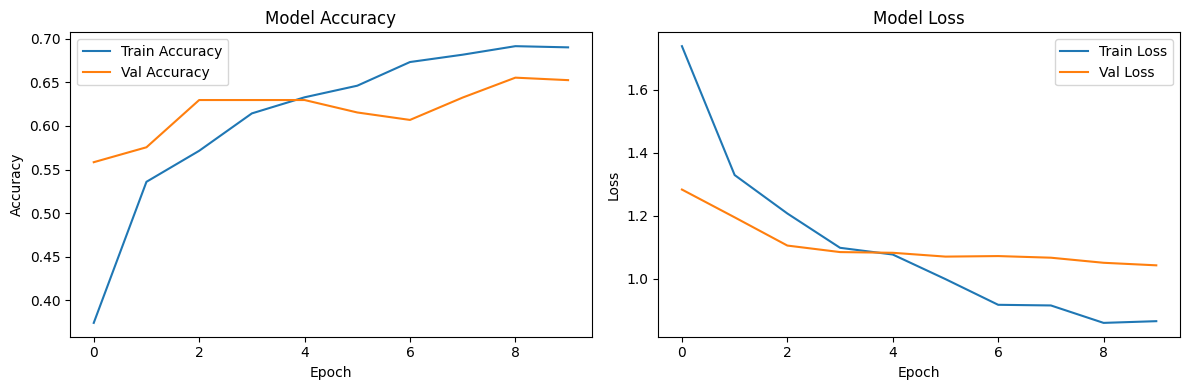

In [ ]:
# Visualize training history
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()